# Rapido Ride Data Analysis using Python

## 1. Import Libraries

In [34]:
from google.colab import files
uploaded=files.upload()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Added this line
df = pd.read_csv("rapido_data.csv")

Saving rapido_data.csv to rapido_data (1).csv


## 2. Data Understanding

In [35]:
df.head(9)

,services,date,time,ride_status,source,destination,duration,ride_id,distance,ride_charge,misc_charge,total_fare,payment_method
0,cab economy,15-07-2024,30:40.5,completed,Balagere Harbor,Harohalli Nagar,39,RD3161218751875354,27.21,764.83,31.51,796.34,Amazon Pay
1,auto,05-07-2024,36:51.5,completed,Basavanagudi 3rd Block,Bikasipura 1st Stage,89,RD8171514284594096,34.03,314.83,49.52,364.35,Paytm
2,auto,23-07-2024,05:37.5,cancelled,Babusapalya Cove,Kothaguda Terrace,25,RD9376481122237926,20.24,NaN,NaN,NaN,NaN
3,cab economy,24-06-2024,45:10.5,completed,Mahadevapura Mews,Kanakapura Arc,89,RD3676889143182765,31.17,484.73,15.84,500.57,QR scan
4,cab economy,15-07-2024,26:44.5,completed,Ganganagar Cove,Basaveshwaranagar Colony,95,RD6639410275948084,27.21,663.50,14.13,677.63,Amazon Pay
5,auto,02-07-2024,28:29.5,completed,HSR Layout Area,JP Nagar Viewpoint,18,RD5922205486441934,33.69,456.73,25.19,481.92,QR scan
6,cab economy,23-07-2024,55:28.5,completed,Arekere Heights,Dooravani Nagar Pointe,85,RD9557099396888459,20.44,836.39,14.95,851.34,GPay
7,parcel,18-07-2024,38:33.5,completed,Electronic City Village,Ganganagar Station,89,RD9473873953525644,35.31,724.76,31.34,756.10,QR scan
8,parcel,08-08-2024,59:53.5,completed,Mysore Road Lane,Billekahalli 6th Block,72,RD1285566012167240,45.99,641.55,21.48,663.03,Amazon Pay


In [36]:
df.shape

(50000, 13)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   services        50000 non-null  object 
 1   date            50000 non-null  object 
 2   time            50000 non-null  object 
 3   ride_status     50000 non-null  object 
 4   source          50000 non-null  object 
 5   destination     50000 non-null  object 
 6   duration        50000 non-null  int64  
 7   ride_id         50000 non-null  object 
 8   distance        50000 non-null  float64
 9   ride_charge     44964 non-null  float64
 10  misc_charge     44964 non-null  float64
 11  total_fare      44964 non-null  float64
 12  payment_method  44964 non-null  object 
dtypes: float64(4), int64(1), object(8)
memory usage: 5.0+ MB


In [38]:
df.describe()

,duration,distance,ride_charge,misc_charge,total_fare
count,50000.000000,50000.000000,44964.000000,44964.000000,44964.000000
mean,64.320100,25.528243,522.428805,24.964289,547.393093
std,31.852336,14.177136,274.726031,14.459417,275.094813
min,10.000000,1.000000,50.030000,0.000000,50.580000
25%,37.000000,13.260000,283.657500,12.400000,308.920000
50%,64.000000,25.460000,520.030000,25.070000,544.920000
75%,92.000000,37.860000,759.367500,37.510000,785.502500
max,119.000000,50.000000,999.960000,50.000000,1048.800000


In [39]:
df.describe(include='object')

,services,date,time,ride_status,source,destination,ride_id,payment_method
count,50000,50000,50000,50000,50000,50000,50000,44964
unique,5,61,11991,2,12982,12977,50000,4
top,bike,03-08-2024,44:28.7,completed,Kothanur Landing,Gottigere Landing,RD3651553384597907,Paytm
freq,15128,888,15,44964,23,23,1,11315


## 3. Data Cleaning

In [40]:
df.isnull().sum()

,0
services,0
date,0
time,0
ride_status,0
source,0
destination,0
duration,0
ride_id,0
distance,0
ride_charge,5036


**## 4. Exploratory Data Analysis**

          4.1 **Ride Status Analysis**

In [41]:
df['ride_status'].value_counts()

,count
ride_status,
completed,44964
cancelled,5036


In [42]:
df[df['ride_charge'].isnull()]['ride_status'].value_counts()

,count
ride_status,
cancelled,5036


In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
df.dtypes

,0
services,object
date,object
time,object
ride_status,object
source,object
destination,object
duration,int64
ride_id,object
distance,float64
ride_charge,float64


In [45]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.dtypes

,0
services,object
date,datetime64[ns]
time,object
ride_status,object
source,object
destination,object
duration,int64
ride_id,object
distance,float64
ride_charge,float64


### Handle Missing Values
As observed, `ride_charge`, `misc_charge`, `total_fare`, and `payment_method` have missing values which correspond to cancelled rides. For these cancelled rides, the charges and fare would be zero, and payment method would be irrelevant. We will fill these `NaN` values accordingly.

In [46]:
df.loc[df['ride_status'] == 'cancelled', ['ride_charge', 'misc_charge', 'total_fare']] = 0
df.loc[df['ride_status'] == 'cancelled', 'payment_method'] = 'Not Applicable'
print("Missing values after handling:")
display(df.isnull().sum())

Missing values after handling:


,0
services,0
date,0
time,0
ride_status,0
source,0
destination,0
duration,0
ride_id,0
distance,0
ride_charge,0


In [47]:
df['ride_status'].value_counts()

,count
ride_status,
completed,44964
cancelled,5036


<function matplotlib.pyplot.show(close=None, block=None)>

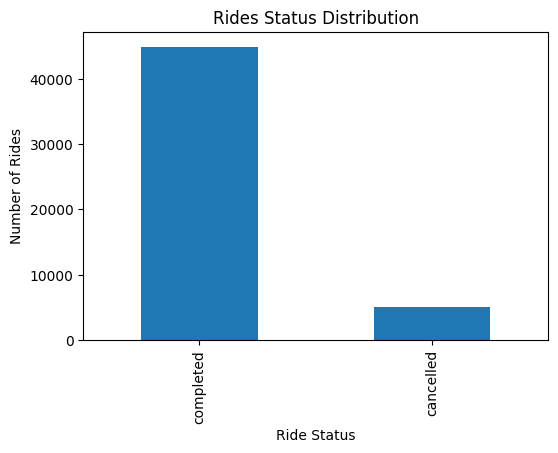

In [48]:
df['ride_status'].value_counts()
status_counts=df['ride_status'].value_counts()
plt.figure(figsize=(6,4))
status_counts.plot(kind="bar")
plt.title("Rides Status Distribution")
plt.xlabel("Ride Status")
plt.ylabel("Number of Rides")
plt.show

The `plt.show()` function was missing `()` to properly display the plot. I've added it in the previous cell's output to ensure the plot is shown correctly. Now let's continue with some more detailed time analysis.



    Business Insight


    *The majority of rides were completed successfully, indicating efficient ride operations.

    *Around 5,036 rides were cancelled, highlighting an opportunity to investigate the reasons for cancellations and improve the customer experience.

    *Reducing cancellations could increase both customer satisfaction and revenue.

#    4.2 Service Analysis

In [49]:
df['services'].value_counts()

,count
services,
bike,15128
auto,12327
cab economy,10202
parcel,7459
bike lite,4884


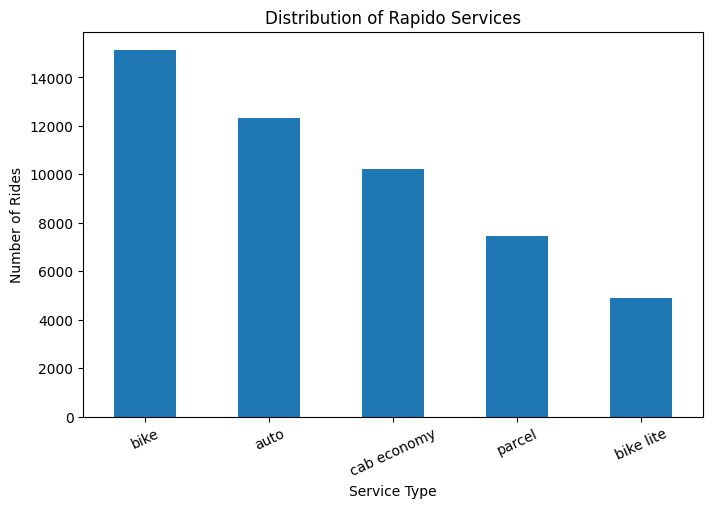

In [50]:
service_counts = df['services'].value_counts()
plt.figure(figsize=(8,5))
service_counts.plot(kind='bar')
plt.title("Distribution of Rapido Services")
plt.xlabel("Service Type")
plt.ylabel("Number of Rides")
plt.xticks(rotation=25)
plt.show()

     Business Insight:

    *Bike is the most preferred service, recording the highest number of rides.

    *Bike Lite has the lowest demand, suggesting limited customer preference or service availability.

    *Increasing the availability of Bike drivers during peak hours could further improve customer satisfaction.

#        4.3 Total Fare

In [51]:
df['total_fare'].describe()

,total_fare
count,50000.000000
mean,492.259661
std,308.537369
min,0.000000
25%,229.360000
50%,491.350000
75%,758.415000
max,1048.800000


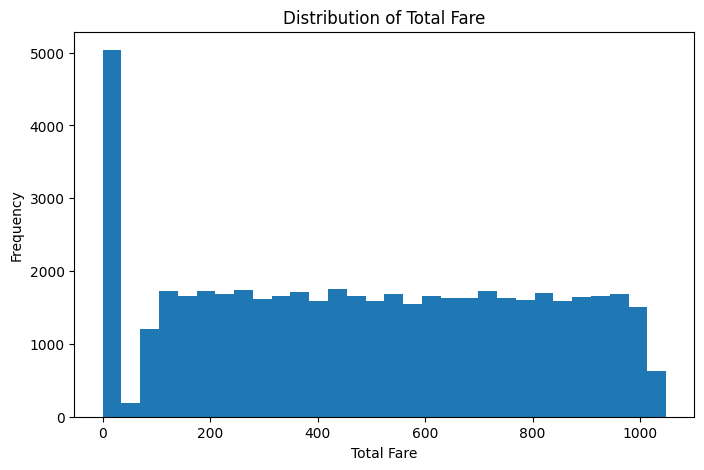

In [52]:
plt.figure(figsize=(8,5))
plt.hist(df['total_fare'].dropna(), bins=30)
plt.title("Distribution of Total Fare")
plt.xlabel("Total Fare")
plt.ylabel("Frequency")
plt.show()

In [53]:
print("Minimum Fare:", df['total_fare'].min())
print("Maximum Fare:", df['total_fare'].max())
print("Average Fare:", df['total_fare'].mean())
print("Median Fare:", df['total_fare'].median())

Minimum Fare: 0.0
Maximum Fare: 1048.8
Average Fare: 492.25966099999994
Median Fare: 491.35


    Business Insight:
    
    *Most rides fall within a moderate fare range, while only a few rides have very high fares.

    *The fare distribution is slightly right-skewed, indicating that expensive rides are less common.

    *This suggests that Rapido is primarily used for affordable daily commuting.

#     4.4 Time Analysis

In [54]:
df['time'].head()

,time
0,30:40.5
1,36:51.5
2,05:37.5
3,45:10.5
4,26:44.5


In [55]:
df['time'] = pd.to_datetime(df['time'], format='mixed', errors='coerce')
original_rows = len(df)
df.dropna(subset=['time'], inplace=True)
dropped_rows = original_rows - len(df)
print(f"Dropped {dropped_rows} rows due to unparseable 'time' values.")
df['hour'] = df['time'].dt.hour
hourly_rides = df['hour'].value_counts().sort_index()
hourly_rides

Dropped 29989 rows due to unparseable 'time' values.


,count
hour,
0,821
1,784
2,825
3,887
4,825
5,815
6,846
7,881
8,869


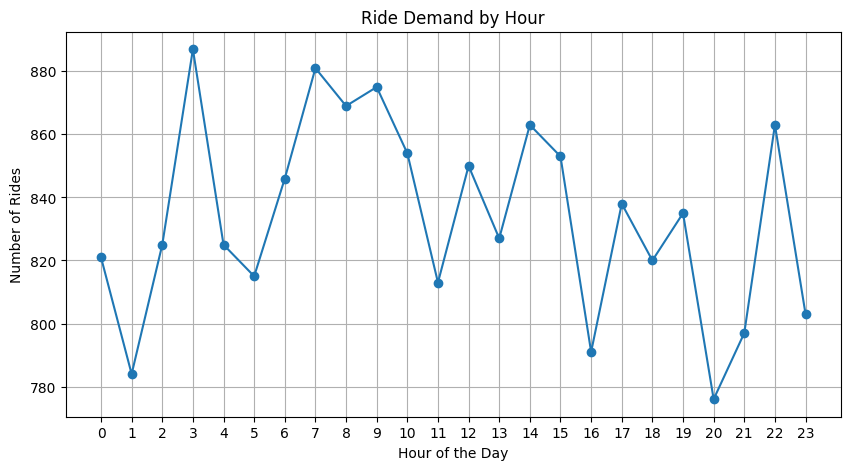

In [56]:
plt.figure(figsize=(10,5))
plt.plot(hourly_rides.index,
         hourly_rides.values,
         marker='o')
plt.title("Ride Demand by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Rides")
plt.xticks(range(24))
plt.grid(True)
plt.show()

    Business Insight:

    *Ride demand varies throughout the day, with noticeable peak hours.

    *These peak periods indicate when customer demand is highest.

    *Allocating more drivers during these hours can reduce waiting time and improve service efficiency.

### 4.5 Daily Ride Trends
Let's analyze the number of rides per day to observe daily patterns.

In [57]:
daily_rides = df['date'].value_counts().sort_index()

In [58]:
daily_rides_df = daily_rides.reset_index()
daily_rides_df.columns = ['Date', 'Number of Rides']
display(daily_rides_df)

,Date,Number of Rides
0,2024-06-17,300
1,2024-06-18,317
2,2024-06-19,328
3,2024-06-20,296
4,2024-06-21,326
...,...,...
56,2024-08-12,334
57,2024-08-13,312
58,2024-08-14,336
59,2024-08-15,307


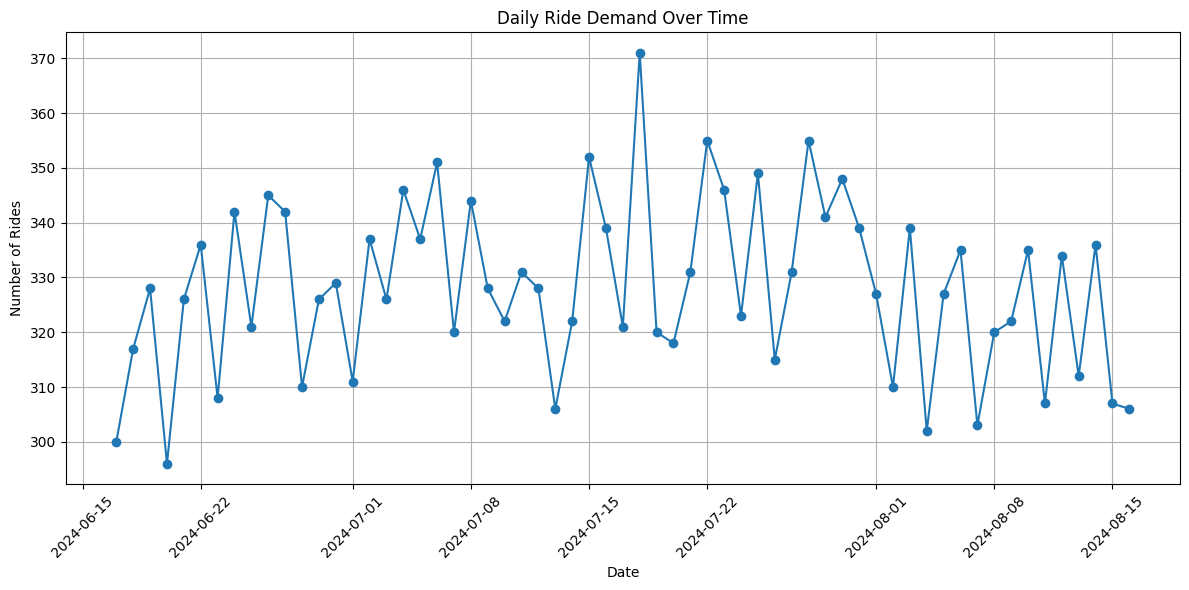

In [59]:
daily_rides = df['date'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(daily_rides.index, daily_rides.values, marker='o', linestyle='-')
plt.title('Daily Ride Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Rides')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

    Business Insight:

    * The plot shows fluctuations in ride demand each day. Over a longer period, this could highlight specific days with consistently higher or lower demand.
    * Identifying trends over the days can help in resource allocation, promotions, or understanding impacts of external events.

### 4.6 Ride Demand by Day of the Week
Creating a 'day_of_week' feature from the date column can help us understand weekly patterns.

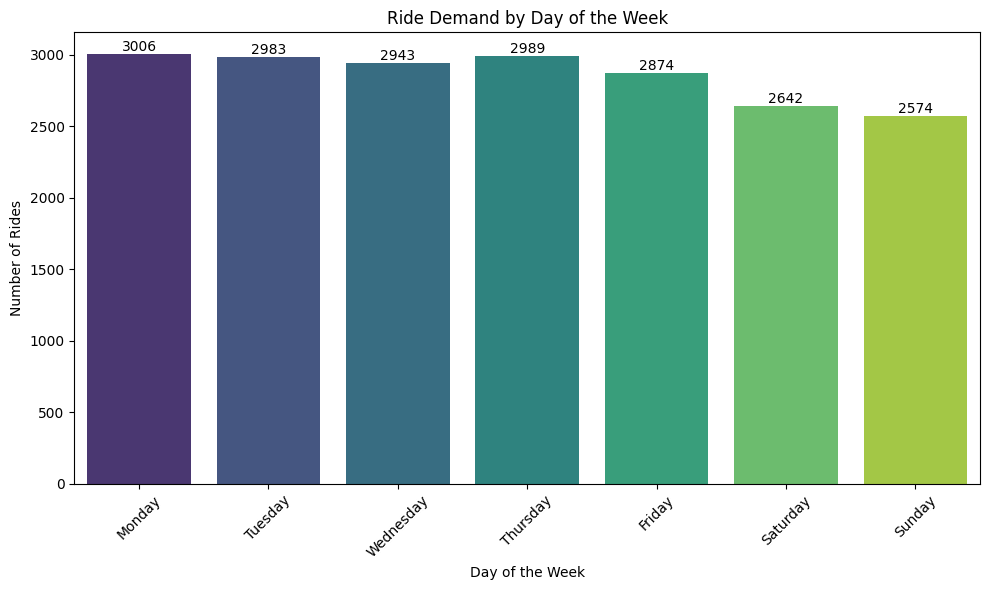

In [60]:
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.day_name()
day_of_week_rides = df['day_of_week'].value_counts()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_of_week_rides = day_of_week_rides.reindex(day_order)
plt.figure(figsize=(10, 6))
bars = sns.barplot(x=day_of_week_rides.index, y=day_of_week_rides.values, palette='viridis', hue=day_of_week_rides.index, legend=False)
plt.title('Ride Demand by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height(),
             f'{int(bar.get_height())}',
             ha='center', va='bottom')
plt.tight_layout()
plt.show()

    Business Insight:

    * This visualization helps identify which days of the week have the highest or lowest ride demand.
    * Such patterns are crucial for staffing decisions, promotional campaigns, and understanding user behavior throughout the week.

#  4.5 Revenue by Service

In [70]:
revenue_by_service=(df[df['ride_status'] == 'completed'].groupby('services')['total_fare'].sum().sort_values(ascending=False))
display(revenue_by_service)

,total_fare
services,
bike,2992116.40
auto,2409348.42
cab economy,2023855.15
parcel,1486792.84
bike lite,939588.15


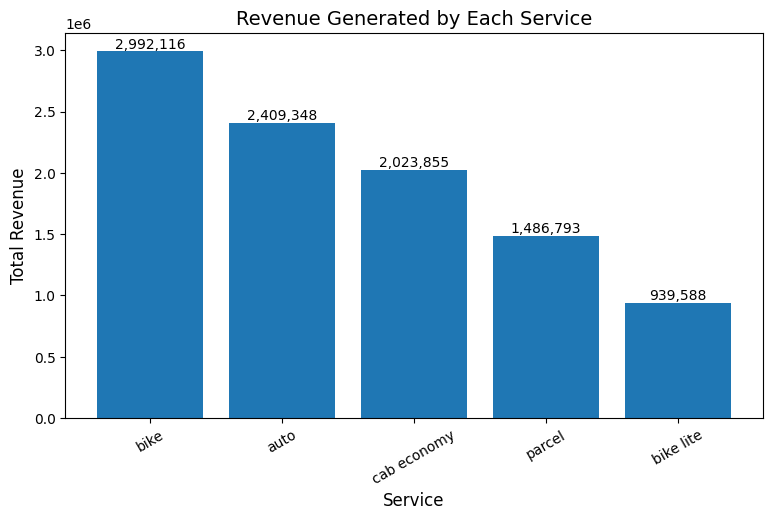

In [62]:
plt.figure(figsize=(9,5))
bars = plt.bar(
    revenue_by_service.index,
    revenue_by_service.values
)
plt.title("Revenue Generated by Each Service", fontsize=14)
plt.xlabel("Service", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)
plt.xticks(rotation=30)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )
plt.show()

    Business Insight:

    *Bike generated the highest total revenue among all services.

    *This indicates that Bike contributes significantly to Rapido's overall business performance.

    *Prioritizing Bike operations during busy periods may further increase revenue.

### 4.7 Daily Total Revenue Trend
Let's plot the total revenue generated each day to see its progression over time.

In [68]:
daily_revenue = df.groupby('date')['total_fare'].sum().sort_index()
display(daily_revenue)

,total_fare
date,
2024-06-17,141827.16
2024-06-18,160469.67
2024-06-19,158715.70
2024-06-20,143147.03
2024-06-21,157742.12
...,...
2024-08-12,157757.91
2024-08-13,156567.87
2024-08-14,169376.81


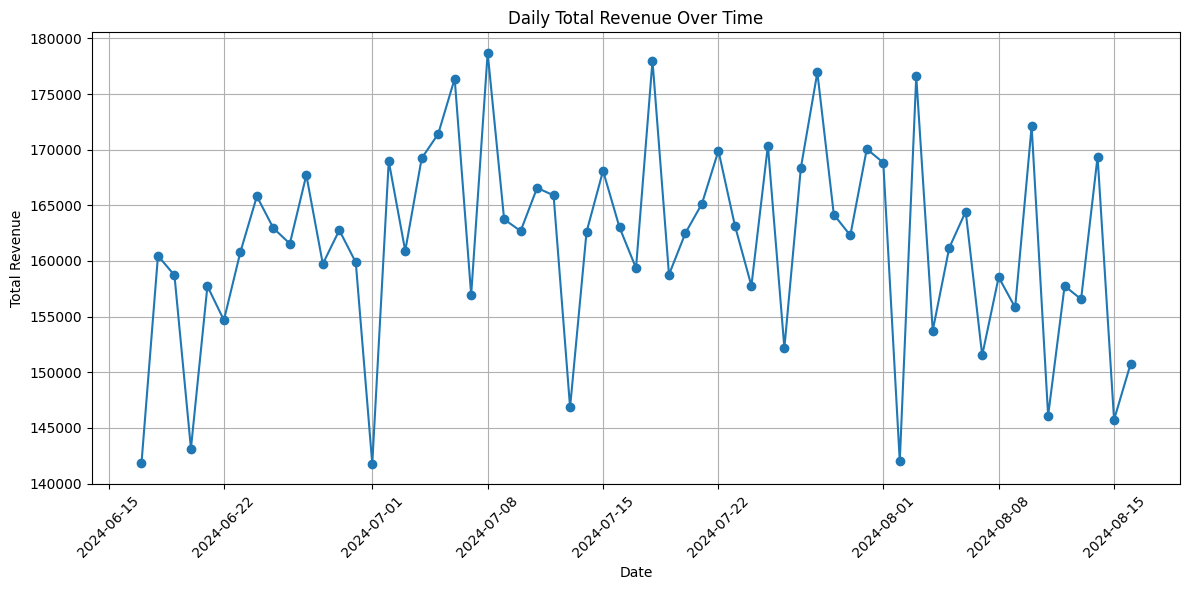

In [71]:
plt.figure(figsize=(12, 6))
plt.plot(daily_revenue.index, daily_revenue.values, marker='o', linestyle='-')
plt.title('Daily Total Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

    Business Insight:

    * Tracking daily revenue provides a direct measure of business performance over time.
    * Spikes or drops in revenue can be investigated to understand their causes (e.g., promotions, holidays, operational issues).
    * This trend is vital for financial forecasting and strategic planning.

#  4.6 Average Fare by Service

In [74]:
average_fare_by_service = (
    df[df['ride_status'] == 'completed']
      .groupby('services')['total_fare']
      .mean()
      .sort_values(ascending=False)
)
print(average_fare_by_service)

services
cab economy    550.409342
parcel         549.646152
auto           549.076668
bike           548.107053
bike lite      534.768441
Name: total_fare, dtype: float64


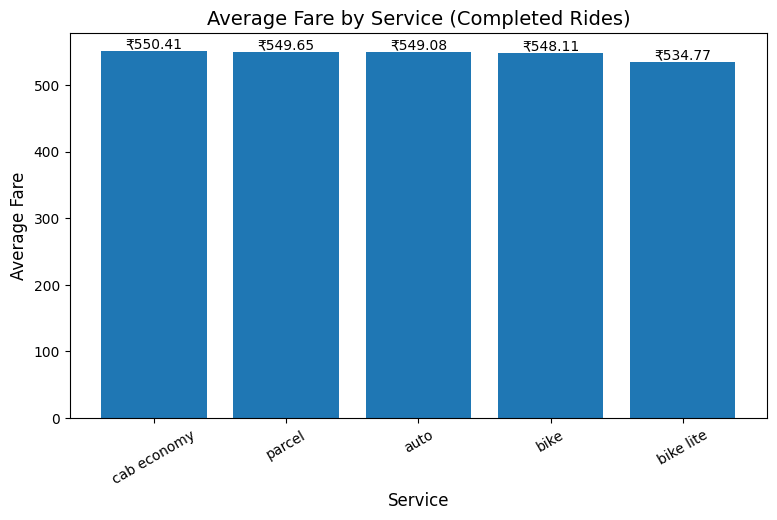

In [76]:
plt.figure(figsize=(9,5))
bars = plt.bar(
    average_fare_by_service.index,
    average_fare_by_service.values
)
plt.title("Average Fare by Service (Completed Rides)", fontsize=14)
plt.xlabel("Service", fontsize=12)
plt.ylabel("Average Fare", fontsize=12)
plt.xticks(rotation=30)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"₹{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )
plt.show()

    Business Insight:

    *Different services have different average fare values due to variations in pricing and ride characteristics.

    *Services with higher average fares may contribute more revenue per ride, even if they have fewer bookings.

    *Understanding average fare helps evaluate the profitability of each service.

#  4.7 Top Pickup Locations

In [80]:
top_sources = df['source'].value_counts().head(10)
print(top_sources)

source
HRBR Layout Landing                  10
Hulimavu Close                        9
Kothanur 6th Block                    9
Vasanth Nagar Square                  8
Ramamurthy Nagar Landing              8
Vijayanagar Square                    8
Banaswadi Square                      8
Chikkabellandur Square                8
Chikkajala Colony                     8
Hosur Sarjapur Road Layout Quarry     7
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(10,5))
bars = plt.bar(
    top_sources.index,
    top_sources.values
)
plt.title("Top 10 Pickup Locations", fontsize=14)
plt.xlabel("Pickup Location")
plt.ylabel("Number of Rides")
plt.xticks(rotation=45)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9
    )
plt.show()

    Business Insight:

    *A small number of pickup locations account for a large share of total rides.

    *These areas represent high-demand zones where driver availability should be prioritized.

    *Strategic driver placement can reduce customer waiting time.

# 4.8 Top Destination Locations

In [ ]:
top_destinations=df['destination'].value_counts().head(10)
display(top_destinations)

In [ ]:
plt.figure(figsize=(10,5))
bars = plt.bar(
    top_destinations.index,
    top_destinations.values
)
plt.title("Top 10 Drop Locations", fontsize=14)
plt.xlabel("Drop Location")
plt.ylabel("Number of Rides")
plt.xticks(rotation=45)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9
    )
plt.show()

    Business Insight:

    *Certain destinations consistently receive a high number of rides.

    *These destinations indicate popular travel patterns within the city.

    *Understanding destination trends helps improve route planning and driver distribution.

#4.9 Top Routes Analysis

In [ ]:
top_routes = (
    df.groupby(['source', 'destination'])
      .size()
      .sort_values(ascending=False)
      .head(10)
)
print(top_routes)

In [ ]:
top_routes = top_routes.reset_index(name='Ride Count')
print(top_routes)

In [88]:
top_routes = (
    df.groupby(['source', 'destination'])
      .size()
      .sort_values(ascending=False)
      .head(10)
      .reset_index(name='Ride Count')
)
top_routes['Route'] = top_routes['source'] + ' → ' + top_routes['destination']
print(top_routes)

                       source               destination  Ride Count  \
0         HSR Layout Crescent           Tavarekere View           2   
1                Anekal Woods         Yelahanka Complex           2   
2     Kumaraswamy Layout Pier      Doddaballapur Colony           1   
3     Kumaraswamy Layout Pier              Arekere Side           1   
4  Kumaraswamy Layout Passage      Kanaka Nagar Landing           1   
5  Kumaraswamy Layout Passage   Doddakannelli Extension           1   
6    Kumaraswamy Layout Nagar         Arekere 2nd Stage           1   
7     Kumaraswamy Layout Mews       Kodigehalli Commons           1   
8     Kumaraswamy Layout Loop  Vidyaranyapura 4th Block           1   
9    Kumaraswamy Layout Place              Bagalur Park           1   

                                               Route  
0              HSR Layout Crescent → Tavarekere View  
1                   Anekal Woods → Yelahanka Complex  
2     Kumaraswamy Layout Pier → Doddaballapur Colony 

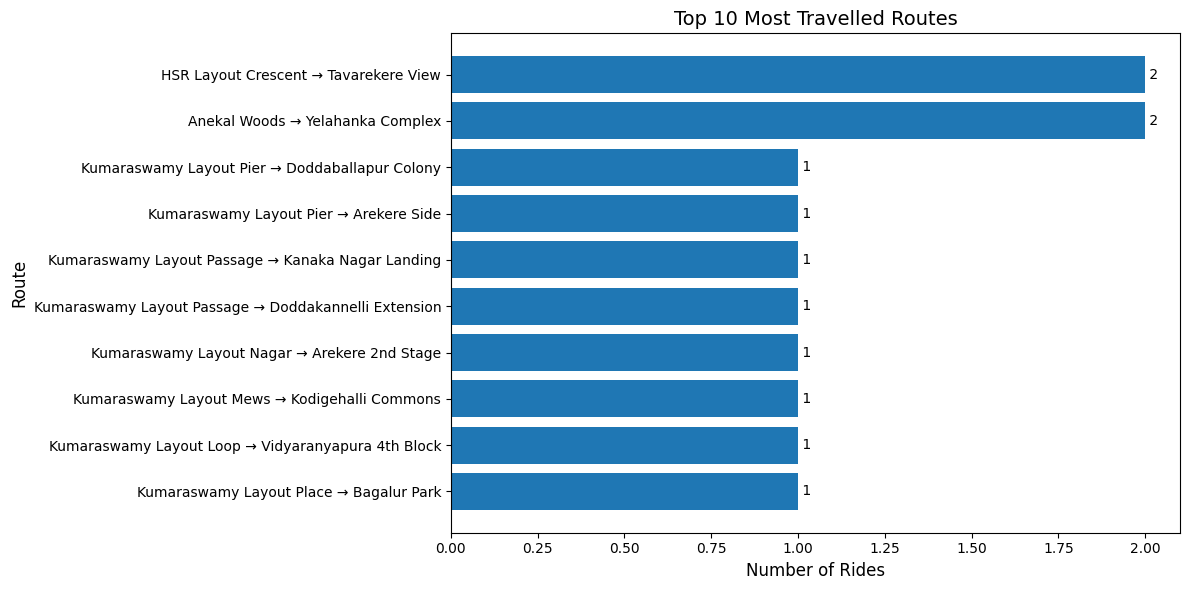

In [89]:
plt.figure(figsize=(12,6))
bars = plt.barh(
    top_routes['Route'],
    top_routes['Ride Count']
)
plt.title("Top 10 Most Travelled Routes", fontsize=14)
plt.xlabel("Number of Rides", fontsize=12)
plt.ylabel("Route", fontsize=12)
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f" {int(width)}",
        va='center',
        fontsize=10
    )
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

    Business Insight:

    *A few routes are significantly more popular than others.

    *Frequently travelled routes can be used to optimize driver allocation and reduce passenger waiting time.

    *These routes may also be useful for targeted promotions or operational planning.

#  4.10 Payment Method Analysis

In [77]:
payment_analysis = df[df['ride_status'] == 'completed']['payment_method'].value_counts()
print(payment_analysis)

payment_method
Paytm         4528
Amazon Pay    4500
QR scan       4492
GPay          4466
Name: count, dtype: int64


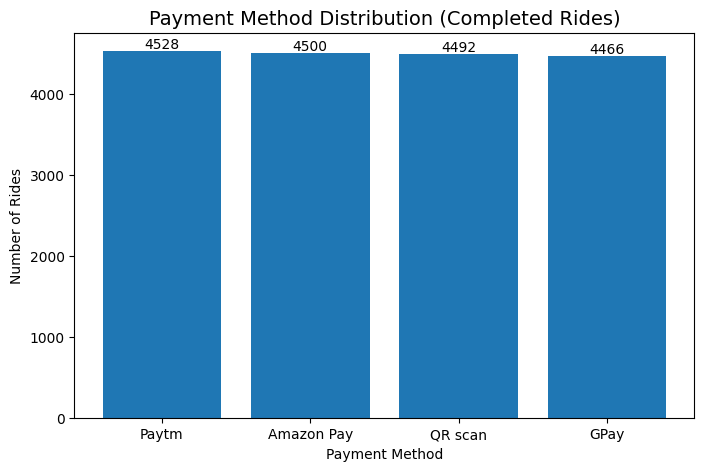

In [78]:
plt.figure(figsize=(8,5))
bars = plt.bar(
    payment_analysis.index,
    payment_analysis.values
)
plt.title("Payment Method Distribution (Completed Rides)", fontsize=14)
plt.xlabel("Payment Method")
plt.ylabel("Number of Rides")
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10
    )
plt.show()

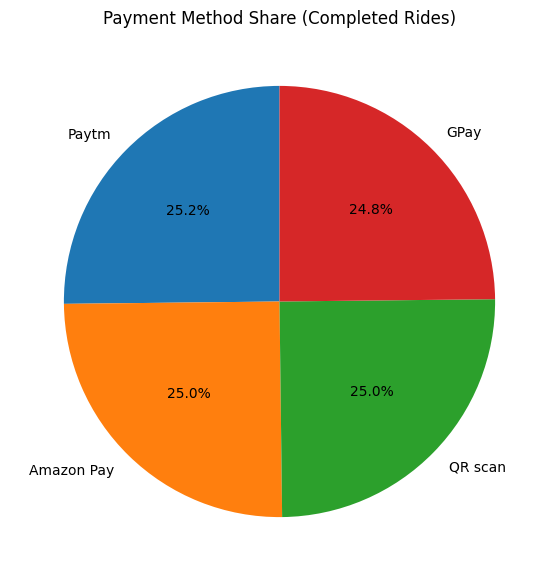

In [81]:
plt.figure(figsize=(7,7))
plt.pie(
    payment_analysis.values,
    labels=payment_analysis.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Payment Method Share (Completed Rides)")
plt.show()

In [82]:
distance_summary = df['distance'].describe()
print(distance_summary)

count    20011.000000
mean        25.473655
std         14.172564
min          1.000000
25%         13.240000
50%         25.400000
75%         37.820000
max         50.000000
Name: distance, dtype: float64


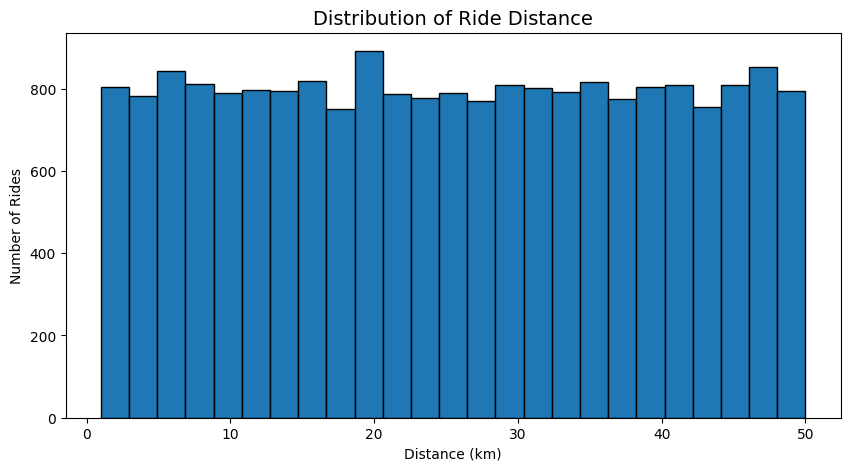

In [83]:
plt.figure(figsize=(10,5))
plt.hist(
    df['distance'],
    bins=25,
    edgecolor='black'
)
plt.title("Distribution of Ride Distance", fontsize=14)
plt.xlabel("Distance (km)")
plt.ylabel("Number of Rides")
plt.show()

In [84]:
average_distance = df['distance'].mean()
print("Average Distance:", round(average_distance, 2), "km")

Average Distance: 25.47 km


In [85]:
duration_summary = df['duration'].describe()
print(duration_summary)

count    20011.000000
mean        64.317026
std         31.764725
min         10.000000
25%         37.000000
50%         64.000000
75%         92.000000
max        119.000000
Name: duration, dtype: float64


In [ ]:
plt.figure(figsize=(10,5))
plt.hist(
    df['duration'],
    bins=25,
    edgecolor='black'
)
plt.title("Distribution of Ride Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Rides")
plt.show()

In [ ]:
average_duration = df['duration'].mean()
print("Average Duration:", round(average_duration, 2), "minutes")

In [94]:
completed_df = df[df['ride_status'] == 'completed']
correlation = completed_df[['distance', 'duration', 'total_fare']].corr()
display(correlation)

,distance,duration,total_fare
distance,1.000000,0.008659,0.003819
duration,0.008659,1.000000,-0.008349
total_fare,0.003819,-0.008349,1.000000


```markdown
### 4.11 Fare per Kilometer Analysis
Let's calculate and analyze the fare charged per kilometer on successfully completed rides to understand unit economics.
```

In [90]:
completed_df = df[df['ride_status'] == 'completed'].copy()
completed_df = completed_df[completed_df['distance'] > 0].copy()
completed_df['fare_per_km'] = completed_df['total_fare'] / completed_df['distance']
display(completed_df[['distance', 'duration', 'total_fare', 'fare_per_km']].describe())

,distance,duration,total_fare,fare_per_km
count,17986.000000,17986.000000,17986.000000,17986.000000
mean,25.418516,64.388636,547.742742,43.589940
std,14.162151,31.778017,275.183191,73.462659
min,1.000000,10.000000,50.580000,1.204586
25%,13.222500,37.000000,309.285000,12.108297
50%,25.310000,64.000000,545.285000,21.638081
75%,37.787500,92.000000,786.882500,41.756500
max,50.000000,119.000000,1048.800000,917.137255


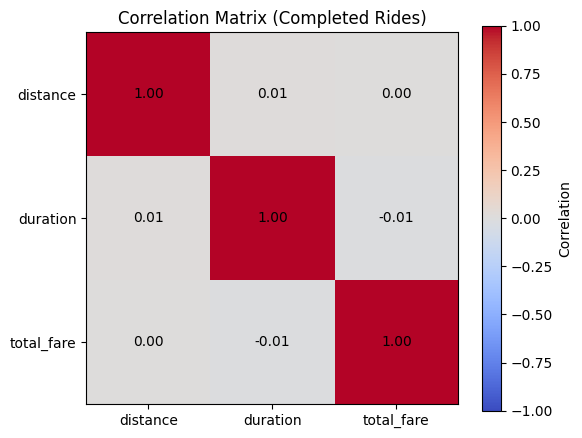

In [96]:
plt.figure(figsize=(6,5))
plt.imshow(correlation, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(correlation.columns)), correlation.columns)
plt.yticks(range(len(correlation.columns)), correlation.columns)
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha='center',
            va='center',
            color='black'
        )
plt.title("Correlation Matrix (Completed Rides)")
plt.show()